<a href="https://colab.research.google.com/github/jollyoli93/KnowYourLoadExactly/blob/main/Crane_Detector_StandardCrop_(Main).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
!pip install ultralytics==8.3.190

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.6 MB/s eta 0:00:00


In [2]:
!pip install --upgrade onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 90.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.0/680.0 kB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.5/127.5 kB 14.0 MB/s eta 0:00:00


In [3]:
# !pip install wandb

In [4]:
# from wandb.integration.ultralytics import add_wandb_callback
from ultralytics import YOLO
import cv2
import numpy as np
import torch

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [42]:
%cd /content/drive/MyDrive/Crane-Detector

/content/drive/MyDrive/Crane-Detector


## Load YOLO Model

In [6]:
best_weights = "/content/drive/MyDrive/Crane-Detector/First Experiment/runs/obb/Best_Standard/weights/best.pt"

In [69]:
yolo_model = YOLO(best_weights)

In [70]:
test_path = "/content/drive/MyDrive/Crane-Detector/First Experiment/ALL_2CLS_NOAUG/test/images"

In [71]:
# from pathlib import Path

# results = []

# for img in Path(test_path).glob("*jpg"):
#   results.append(model.predict(img, stream=False))

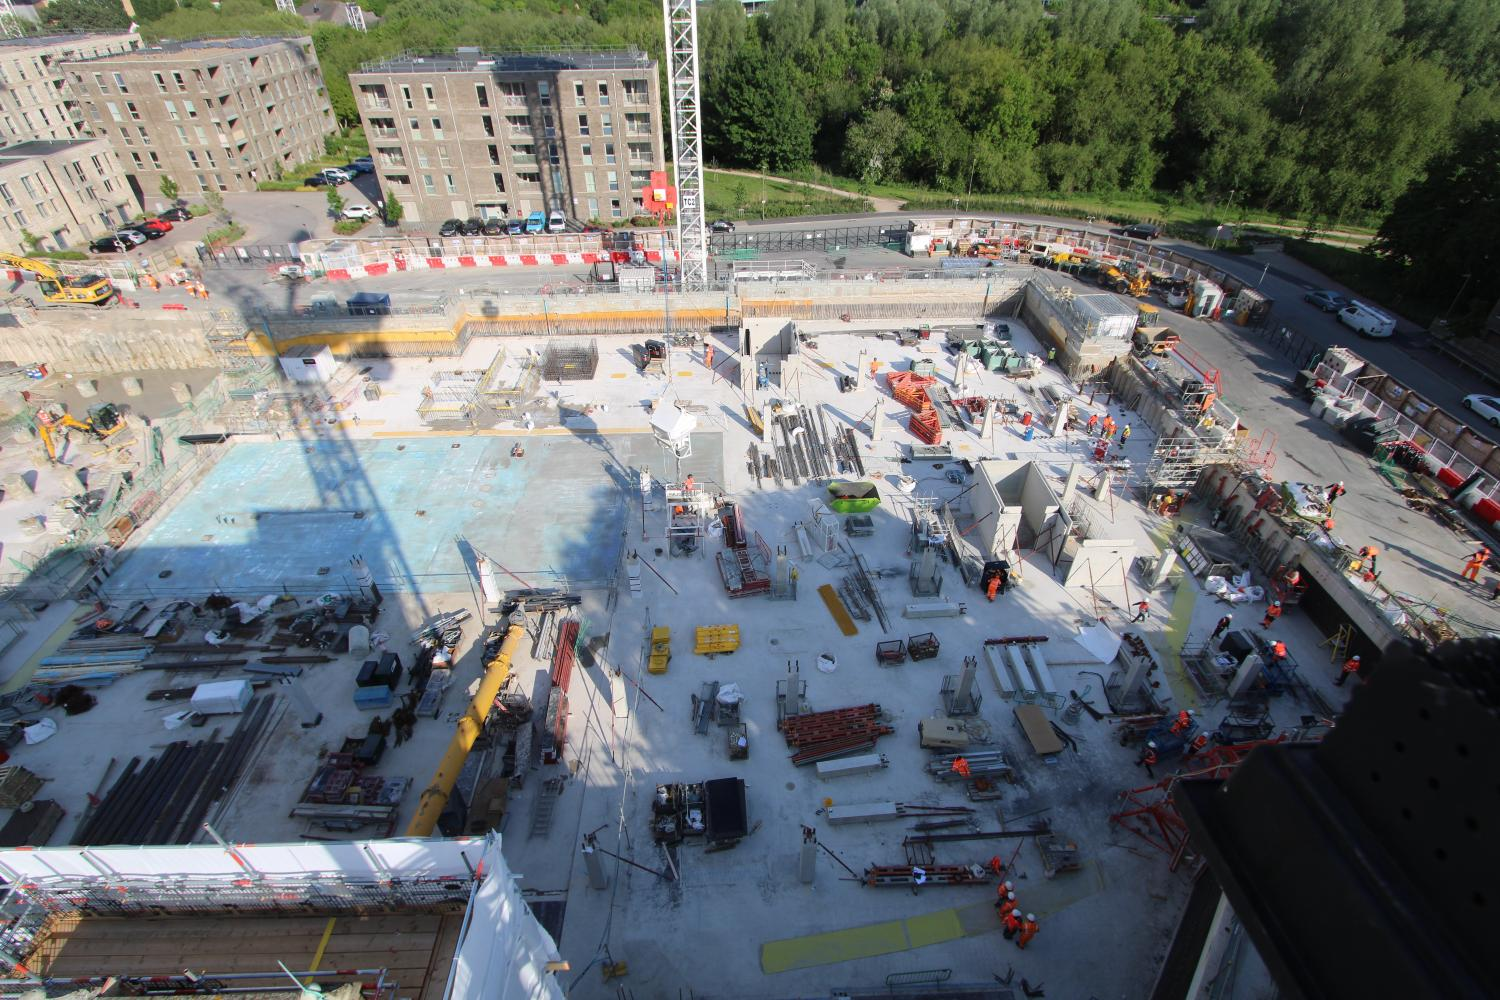

In [188]:
from google.colab.patches import cv2_imshow

# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/valid/images/2502240810060000_jpg.rf.56156243b1ad02bee4d57d2e65850cca.jpg') #1 hook, 1 load

# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301040060000_jpg.rf.e1ed3ff61e40b48bd7aecdf5f7df6050.jpg') #1 hook, 1 load
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505301210060000_jpg.rf.4e2d4447ae977df17c79484f248ebb27.jpg') # 2 hook
# img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505081520060000_jpg.rf.0d654dfb0aa7f32b6b1385e4ae5c7e5f.jpg')  #1 hook, 1 load
img = cv2.imread('/content/drive/MyDrive/Crane-Detector/First Experiment/All_2LCS_AUG/test/images/2505081740060000_jpg.rf.f446e77de4d540793a42f8ff9e3e8cda.jpg')  #1 hook, 1 load real
cv2_imshow(img)


## Load Regression Model

In [189]:
import torch

class LinearRegression(torch.nn.Module):
    def __init__(self, in_feat, out_feat, hidden) -> None:
        super().__init__()
        self.linear = torch.nn.Sequential(
            torch.nn.Linear(in_feat, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, out_feat),
            torch.nn.Sigmoid()
        )

    def forward(self, x):
        x = self.linear(x)
        return x

In [190]:
cropPredict = LinearRegression(14, 2, 512)
cropPredict.load_state_dict(torch.load("/content/drive/MyDrive/Crane-Detector/LoadRegressionModel/LoadRegressionDims", weights_only=True, map_location=torch.device('cpu')))
cropPredict.eval()

LinearRegression(
  (linear): Sequential(
    (0): Linear(in_features=14, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=2, bias=True)
    (5): Sigmoid()
  )
)

In [191]:
def predict_load_crop(hook_coords, img_size, dims):
  img_width = img_size[1]
  img_height = img_size[0]
  print(f"Predicting new coords")

  xn = dims[0]/img_width
  yn = dims[1]/img_height
  width_n = dims[2]/img_width
  height_n = dims[3]/img_height
  area = width_n*height_n
  ratio = width_n/height_n

  input = torch.concat((hook_coords, torch.tensor([width_n]), torch.tensor([height_n]), torch.tensor([area]), torch.tensor([ratio]),
                        torch.tensor([xn]), torch.tensor([yn])), axis=0) #dims


  predict = cropPredict(input) #x, y
  img_dims = torch.tensor([img_width, img_height])
  xtens,ytens = predict*img_dims

  xc, yc = int(xtens), int(ytens)

  # Toggle size of crop with respect to size of image
  w , h = int(img_width*0.07), int(img_height*0.07)

  #Get top left and top right x,y
  yt = yc - (h//2)
  xt = xc - (w//2)

  print(f"Crop dims: {xt, yt, w, h}")
  return xt, yt, w, h

  # return standard_size #Return top left and bottom right to crop

In [192]:
def crop_load(img, x, y, w, h):
  """
    Takes as input, top left corner, width and height.
  """
  crop_img = img.copy()
  cropped_img = crop_img[y:y+h,x:x+w]

  return cropped_img


## Load Classifier Model

In [193]:
%cd Image_Classes

[Errno 2] No such file or directory: 'Image_Classes'
/content/drive/MyDrive/Crane-Detector/Image_Classes


In [194]:
import torch
import albumentations as A
import numpy as np

checkpoint = torch.load('crane_classifier.pth', map_location='cpu', weights_only=False)

class_model = checkpoint['model']
class_model.eval()

if torch.cuda.is_available():
    class_model = class_model.cuda()

cls_names = checkpoint['cls_names']
cls_index = checkpoint['cls_index']

print("Model loaded successfully!")

Model loaded successfully!


In [195]:
val_transforms = A.Compose([
    A.Resize(height=240, width=240, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), max_pixel_value=255.0),
])

In [196]:
def predict_one_image(model, image_array, transforms=val_transforms):
    """
    Predict class for a single image from test set
    """
    model.eval()

    # Apply transforms
    transformed = transforms(image=image_array)['image']
    x = np.transpose(transformed, (2, 0, 1))
    x = torch.tensor(x, dtype=torch.float32).unsqueeze(0)  # Add batch dimension

    # Move to GPU if available
    if torch.cuda.is_available():
        x = x.cuda()

    with torch.no_grad():
        output = model(x)
        probs = torch.softmax(output, dim=1)
        pred_idx = probs.argmax(dim=1).item()
        confidence = probs[0, pred_idx].item()

    pred_class = cls_names[pred_idx]

    return pred_class, confidence


In [197]:
# Test prediction
predicted_class, confidence = predict_one_image(model, img)

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.4f} ({confidence*100:.2f}%)")

Predicted Class: beams
Confidence: 0.6005 (60.05%)


## Full Crane Load Classifier

In [198]:
# Run prediction on the image
results = yolo_model.predict(img, stream=False)


0: 1088x1600 1 crane_hook, 730.9ms
Speed: 11.0ms preprocess, 730.9ms inference, 2.0ms postprocess per image at shape (1, 3, 1088, 1600)


Class: crane_hook, Box: [642 169 678 225]
Predicting new coords
Crop dims: (606, 286, 105, 70)


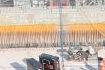

Predicted Cropped Class: rebar
Confidence of Crop: 0.3783 (37.83%)


In [199]:
# Iterate over the results

for result in results:
    boxes = result.obb.cpu()  # Get boxes on CPU in numpy format
    for box in boxes:  # Iterate over boxes
        r = box.xyxy[0].numpy() .astype(int) # Get corner points as int (Actual Co-ords)
        class_id = int(box.cls[0])  # Get class ID
        class_name = yolo_model.names[class_id]  # Get class name using the class ID
        conf = float(box.conf[0])
        print(f"Class: {class_name}, Box: {r}")  # Print class name and box coordinates
        label = f"{class_name}: {conf:.2f}"

        # Get predicted co-ordinates if not load detected

        if class_id == 0: #Hook Class
          coords = box.xyxyxyxyn[0].flatten() #Get all coordinates for prediction
          dims = box.xywhr[0]

          # Predict location for crop
          pts = predict_load_crop(coords, box.orig_shape, dims)
          xt, yt, w, h = pts
          crop = crop_load(img, xt,yt,w,h)
          # crop_resized = cv2.resize(crop, (240, 240))

          # Show cropped region
          cv2_imshow(crop)

          # classify crop
          predicted_class, confidence = predict_one_image(class_model, crop_resized)

          print(f"Predicted Cropped Class: {predicted_class}")
          print(f"Confidence of Crop: {confidence:.4f} ({confidence*100:.2f}%)")

          cv2.rectangle(img, (xt, yt), (xt + w, yt + h), (0, 255, 0), 2)
          cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)

        if class_id == 1: #Load Class
          xt, yt, xb, yb = r
          w, h = box.xywhr.numpy()[0].astype(int)[2:4]
          crop = crop_load(img, xt,yt,w,h)
          crop_resized = cv2.resize(crop, (200, 200))
          cv2_imshow(crop_resized)

          #classify
          predicted_class, confidence = predict_one_image(class_model, crop_resized)
          print(f"Predicted Original Class: {predicted_class}")
          print(f"Confidence of Original: {confidence:.4f} ({confidence*100:.2f}%)")

          cv2.rectangle(img, r[:2], r[2:], (0, 255, 0), 2)
          cv2.putText(img, f"{predicted_class}: {confidence:.2f}", (xt, yt - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2, cv2.LINE_AA)


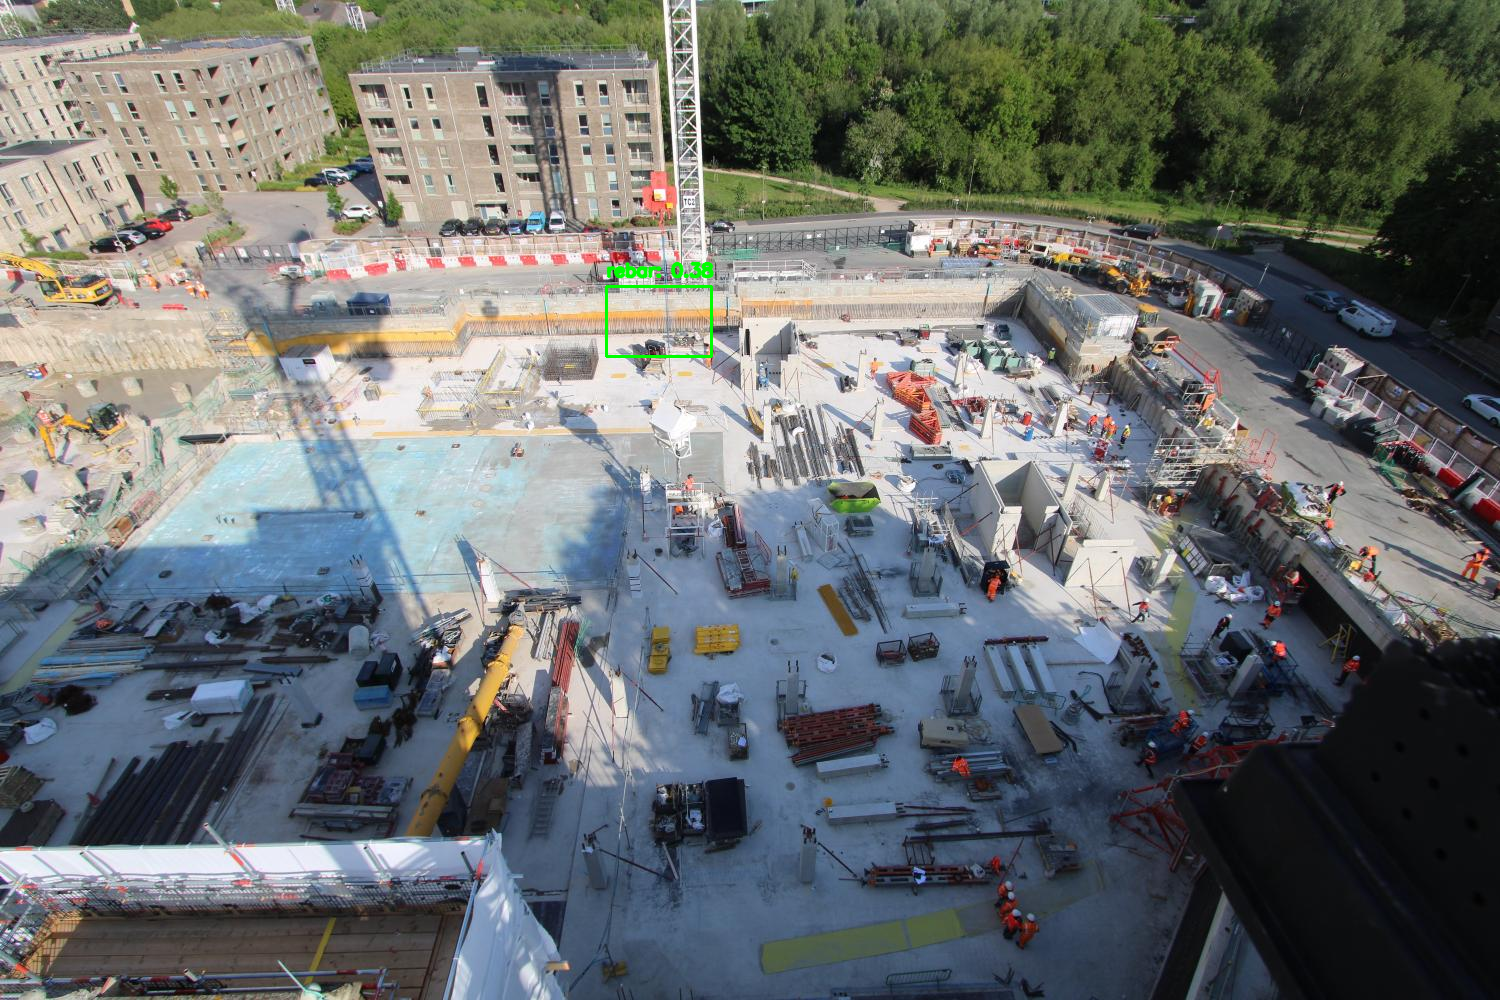

In [200]:
cv2_imshow(img)


## Further Improvement - Notes
  - Model currently off on prediction of locations:
    - Potentially crop several regions, classify each region then NMS on probability
    - More regression training (More data / augmentations? / more features (Height of hook etc).
  - Classification isn't great, 60% in training and doesnt performs too great in this model.
    Suggestions:
      - increase number of training data (More manual crops from lobster cam) and better quality images.
      - Include a not class (Background / Not a load)
      - Play around with transforms and augmentations
      - Increase model architecture.
      - TTA
  - Finish the Muli-Res YOLO model.